# Football Match Analysis

1. Environment & Paths | 2. Feature Engineering (L1/L2/L3) | 3. Ablation (A/B/C/D) | 4. Visualization

## 1. Environment & Paths

In [22]:
# Path setup
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "main.py").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from main import DB_PATH, DATA_PATH
print("DB:", DB_PATH.exists(), "| Data:", DATA_PATH.exists())


DB: True | Data: True


> Data: [Kaggle European Soccer](https://www.kaggle.com/datasets/hugomathien/soccer) → `inputs/raw/database.sqlite`

## 2. Data Preprocessing (Feature Engineering)

In [23]:
# L1/L2/L3 feature engineering
import importlib
import inputs.match_features
importlib.reload(inputs.match_features)
from inputs.match_features import build_match_dataset, load_match_dataset

if not DB_PATH.exists():
    raise FileNotFoundError(f"DB not found: {DB_PATH}")

df = build_match_dataset(DB_PATH, DATA_PATH, min_date="2010-02-22")
df.head(100)


Building features: 100%|██████████| 17969/17969 [07:53<00:00, 37.95it/s]


,match_api_id,date,home_team_api_id,away_team_api_id,home_win,B365H,B365D,B365A,L1_home_overall_mean,L1_away_overall_mean,...,L3_away_win_rate_5,L3_home_gd_5,L3_away_gd_5,L3_home_home_win_rate_5,L3_away_home_win_rate_5,L3_home_rest_days,L3_away_rest_days,L3_home_elo,L3_away_elo,L3_elo_diff
0,684955,2010-02-22,10267,8305,1,1.57,4.00,5.50,80.545455,75.454545,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,0.0
1,659091,2010-02-23,10260,8654,1,1.20,6.50,15.00,81.272727,74.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,0.0
2,704654,2010-02-24,8600,8529,1,2.10,3.30,3.50,77.000000,74.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,0.0
3,704632,2010-02-24,8535,8564,0,2.90,3.10,2.50,78.727273,81.909091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,0.0
4,662463,2010-02-26,10217,9803,0,2.50,3.25,2.80,65.363636,66.909091,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500.0,1500.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,654455,2010-03-06,9851,9829,1,1.85,3.20,4.60,75.272727,74.363636,...,1.0,-2.0,1.0,NaN,1.0,7.0,7.0,1490.0,1510.0,-20.0
96,659099,2010-03-06,8654,8559,0,1.80,3.50,4.50,74.363636,72.454545,...,1.0,-3.0,1.0,NaN,1.0,11.0,7.0,1490.0,1510.0,-20.0
97,654454,2010-03-06,9831,8481,0,2.25,3.10,3.40,72.090909,69.727273,...,0.0,-2.0,-2.0,NaN,0.0,7.0,7.0,1490.0,1490.0,0.0
98,685007,2010-03-06,9865,8634,0,11.00,5.75,1.25,73.454545,84.545455,...,NaN,2.0,NaN,NaN,NaN,6.0,NaN,1510.0,1500.0,10.0


**Feature levels**:
- **L1**: Player static ability (overall, attack, defense, passing, pace, physical, gk)
- **L2**: Team tactical style (buildUpPlay, chanceCreation, defence)
- **L3**: Dynamic state (last 5 win rate, goal diff, Elo, rest days)

## 3. Model Training (A/B/C/D Ablation)

In [24]:
# Ablation: A/B/C/D
from inputs.match_features import load_match_dataset
from models.ablation import run_ablation

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Run Step 2 first: {DATA_PATH}")

df = load_match_dataset(DATA_PATH)
results = run_ablation(df)
display(results)


,model,n_features,test_auc,test_logloss,test_brier,test_acc,threshold
0,A,18,0.686134,0.632075,0.221680,0.641525,0.545
1,B,37,0.684885,0.631403,0.221454,0.637629,0.530
2,C,48,0.690585,0.627986,0.220203,0.628166,0.500
3,D,51,0.698000,0.620338,0.216674,0.646257,0.510


| Model | Features | Description |
|-------|----------|-------------|
| A | L1 | Static ability only |
| B | L1+L2 | + Tactical style |
| C | L1+L2+L3 | + Dynamic state |
| D | C+odds | + Betting odds (B365) |

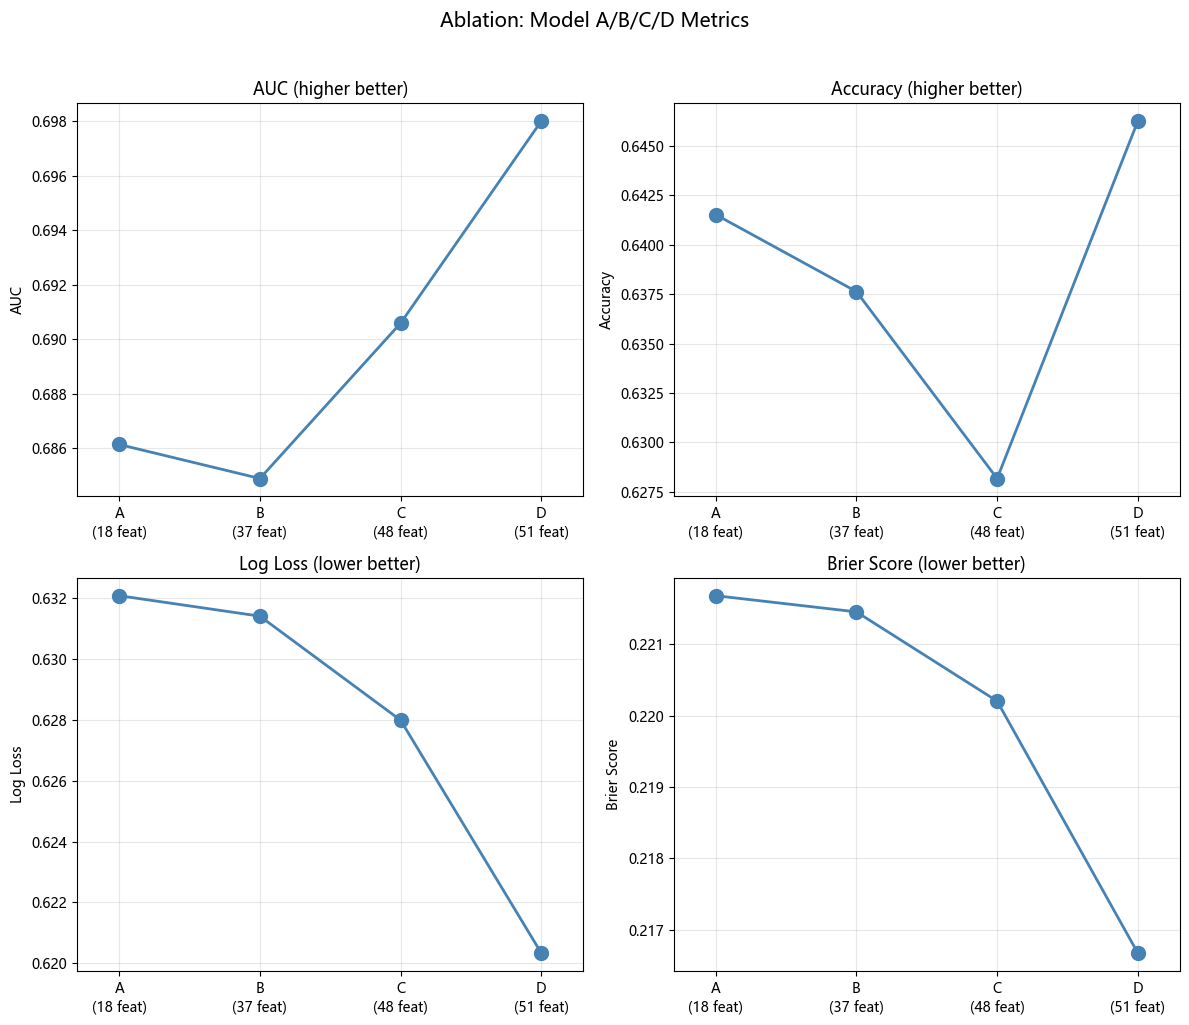

In [25]:
# Metrics line charts
import matplotlib.pyplot as plt
import numpy as np

x_labels = [f"{r['model']}\n({int(r['n_features'])} feat)" for _, r in results.iterrows()]
x_pos = np.arange(len(results))
metrics = [
    ("test_auc", "AUC", "higher better"),
    ("test_acc", "Accuracy", "higher better"),
    ("test_logloss", "Log Loss", "lower better"),
    ("test_brier", "Brier Score", "lower better"),
]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (col, title, note) in zip(axes.flatten(), metrics):
    ax.plot(x_pos, results[col].values, "o-", linewidth=2, markersize=10, color="steelblue")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.set_ylabel(title)
    ax.set_title(f"{title} ({note})")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.3, len(results) - 0.7)
plt.suptitle("Ablation: Model A/B/C/D Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## 4. Visualization

### 4.1 Data Overview

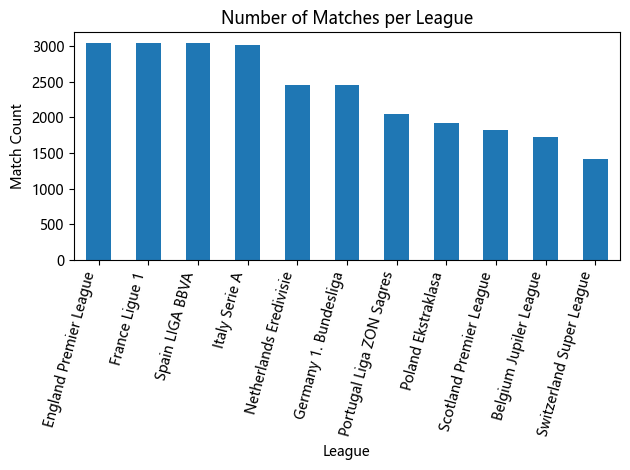

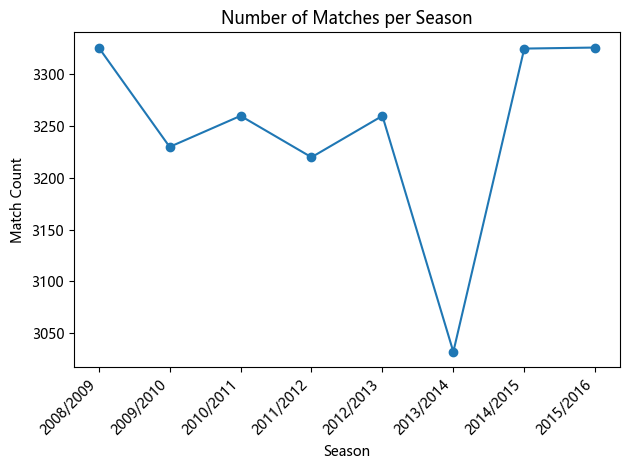

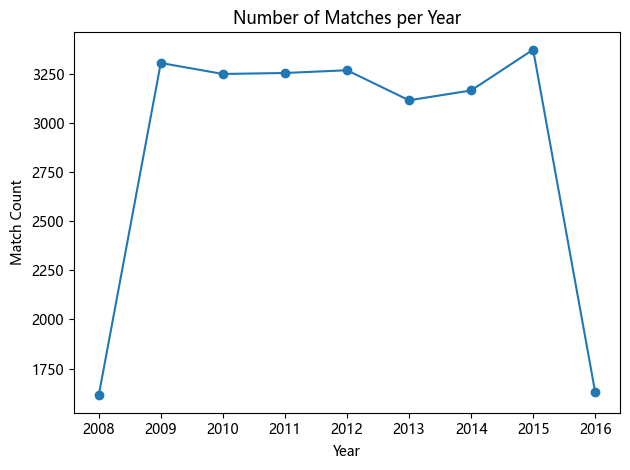

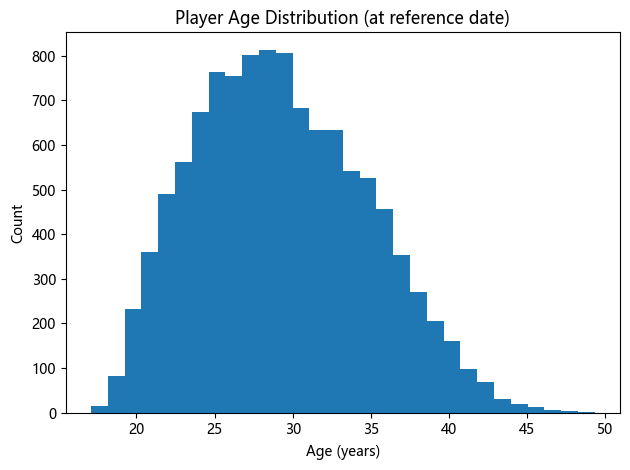

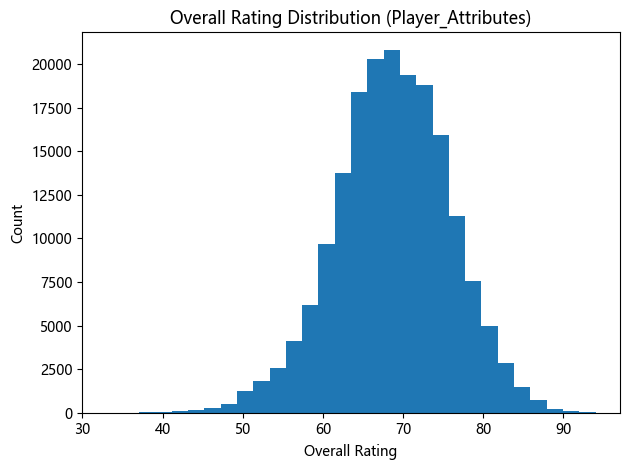

In [26]:
# Data overview plots
from visualization.visualization import (
    load_data_overview,
    plot_matches_per_league,
    plot_matches_per_season,
    plot_matches_per_year,
    plot_player_age_distribution,
    plot_overall_rating_distribution,
)

if DB_PATH.exists():
    overview = load_data_overview(DB_PATH)
    plot_matches_per_league(overview["league_counts"])
    plot_matches_per_season(overview["season_counts"])
    plot_matches_per_year(overview["year_counts"])
    plot_player_age_distribution(overview["player_age"])
    plot_overall_rating_distribution(overview["rating"])


### 4.2 Match & League Stats

c:\Users\sherr\Desktop\campus\143\proj\143_football_match_analysis\visualization\visualization.py:483: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  )


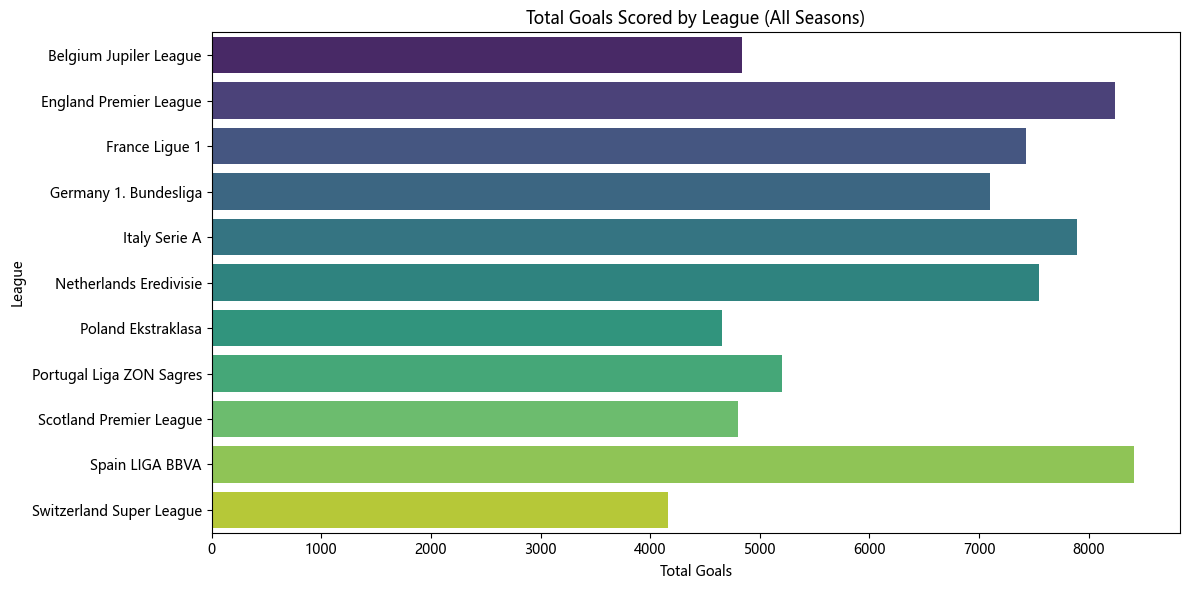

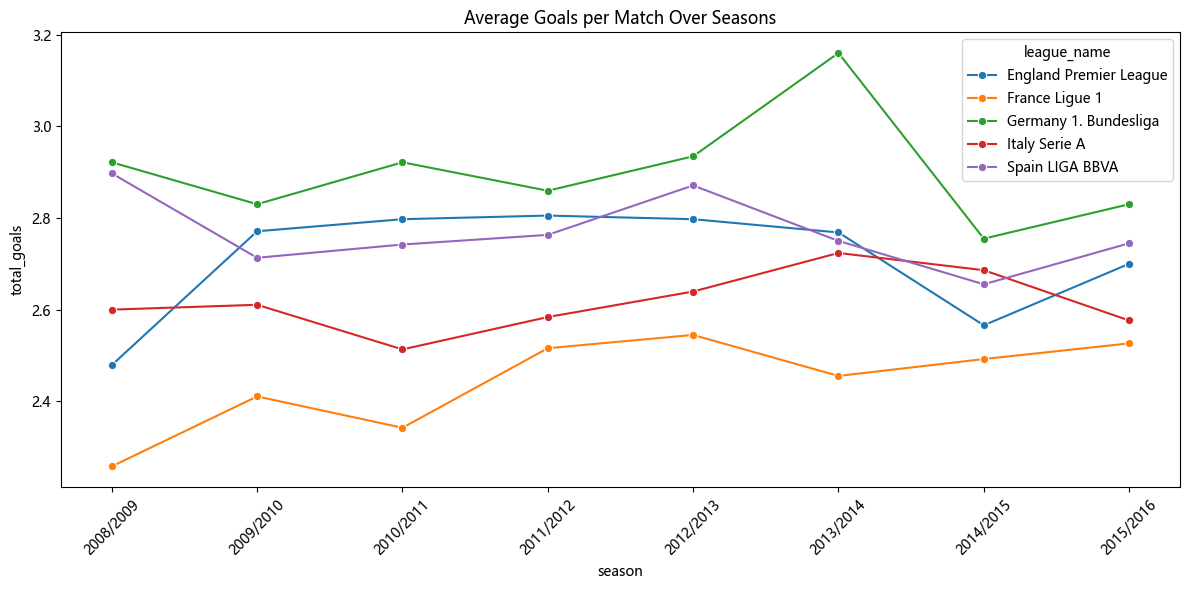

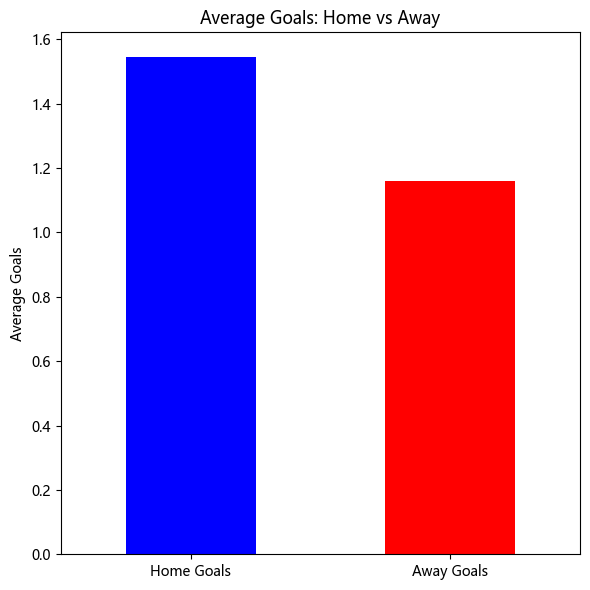

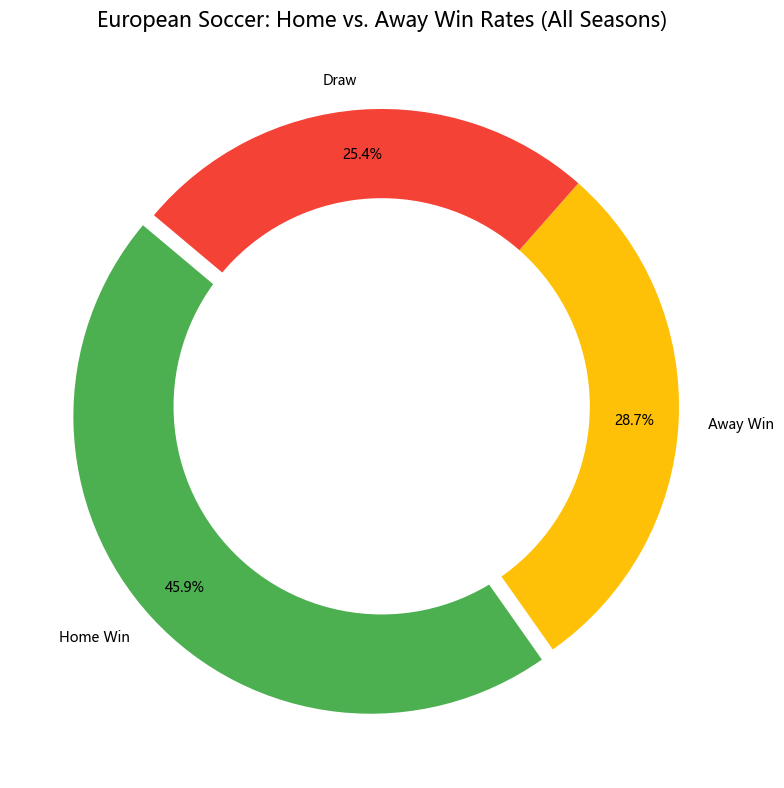

In [27]:
# Match & league stats
from visualization.visualization import (
    load_match_league_df,
    plot_total_goals_by_league,
    plot_goals_over_seasons_by_league,
    plot_home_vs_away_goals,
    load_outcome_counts,
    plot_match_outcome_donut,
)

if DB_PATH.exists():
    df_match = load_match_league_df(DB_PATH)
    plot_total_goals_by_league(df_match)
    plot_goals_over_seasons_by_league(df_match)
    plot_home_vs_away_goals(df_match)
    outcome = load_outcome_counts(DB_PATH)
    plot_match_outcome_donut(outcome)


### 4.3 Feature Impact Analysis

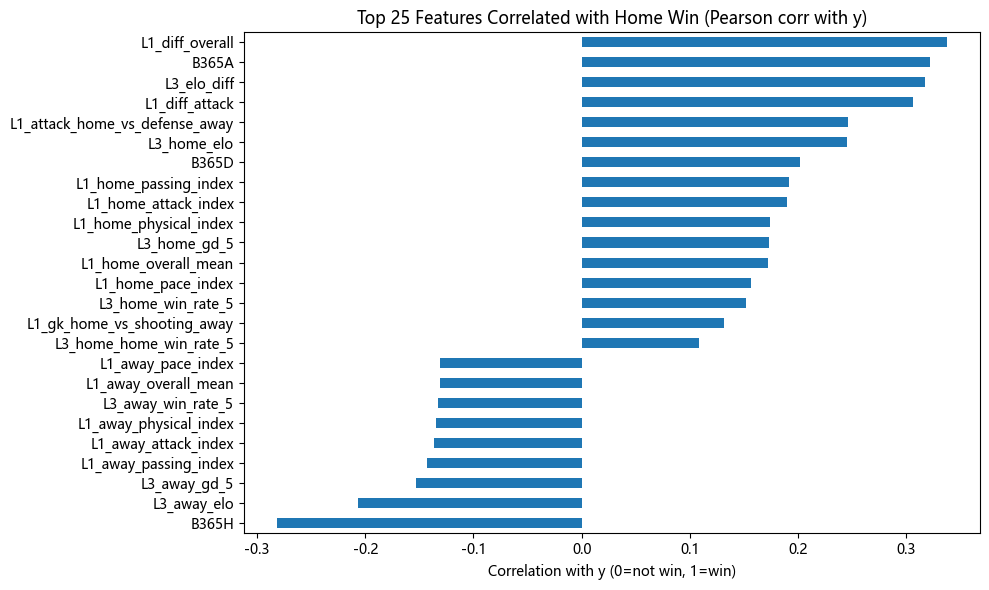

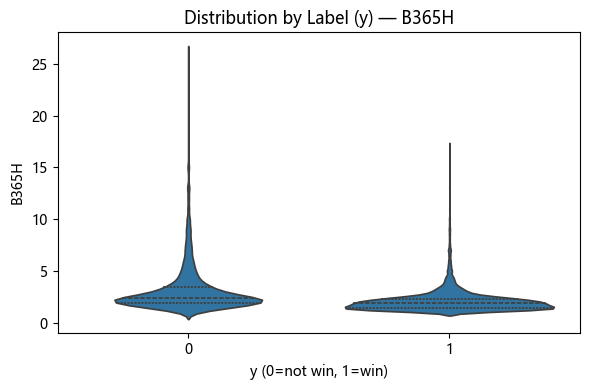

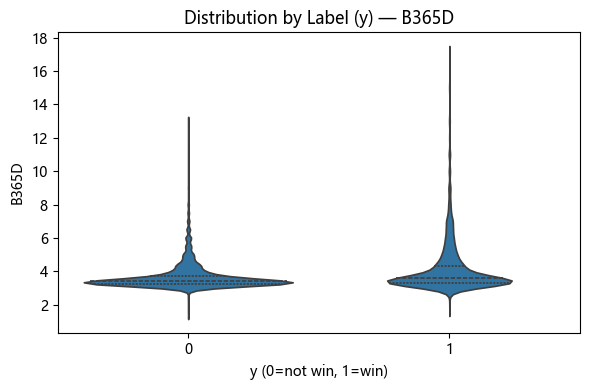

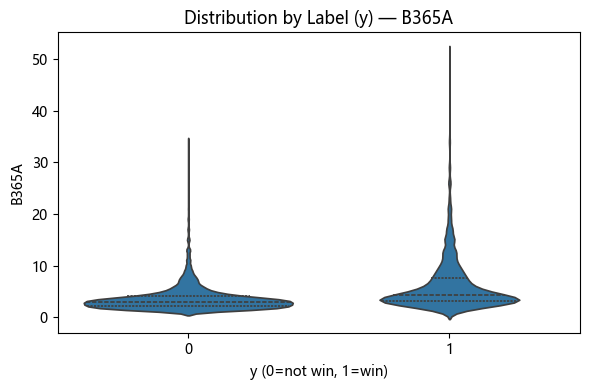

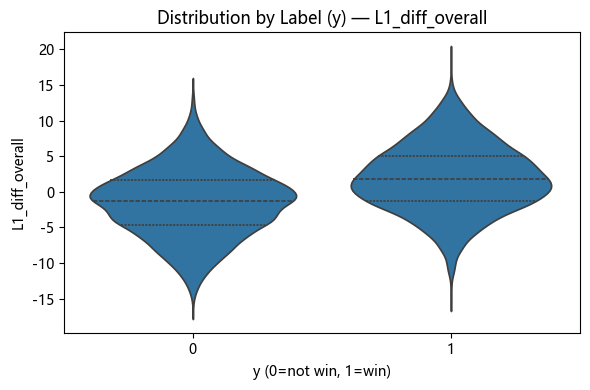

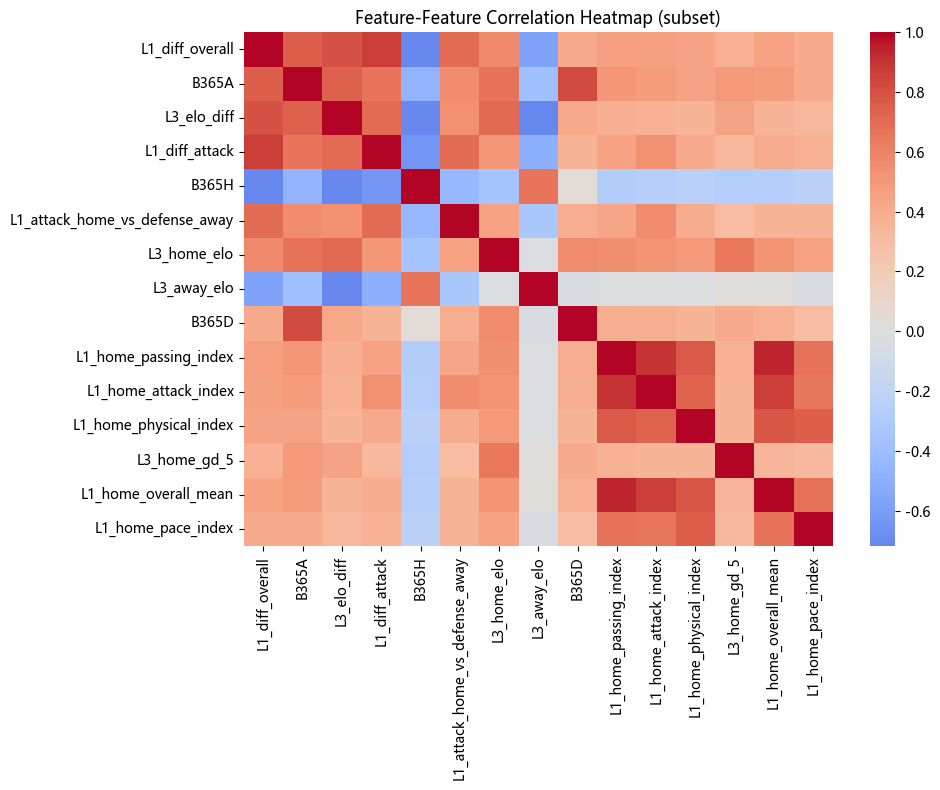

In [28]:
# Feature impact (requires processed_dataset.npz)
from visualization.visualization import (
    load_feature_impact_df,
    plot_feature_correlation_with_outcome,
    plot_feature_distribution_by_label,
    plot_feature_feature_correlation_heatmap,
)

if DATA_PATH.exists():
    df_feat = load_feature_impact_df(DATA_PATH)
    plot_feature_correlation_with_outcome(df_feat, top_k=25)
    plot_feature_distribution_by_label(df_feat, top_k=4)
    plot_feature_feature_correlation_heatmap(df_feat, top_k=15)


### 4.4 Player & Team Analysis

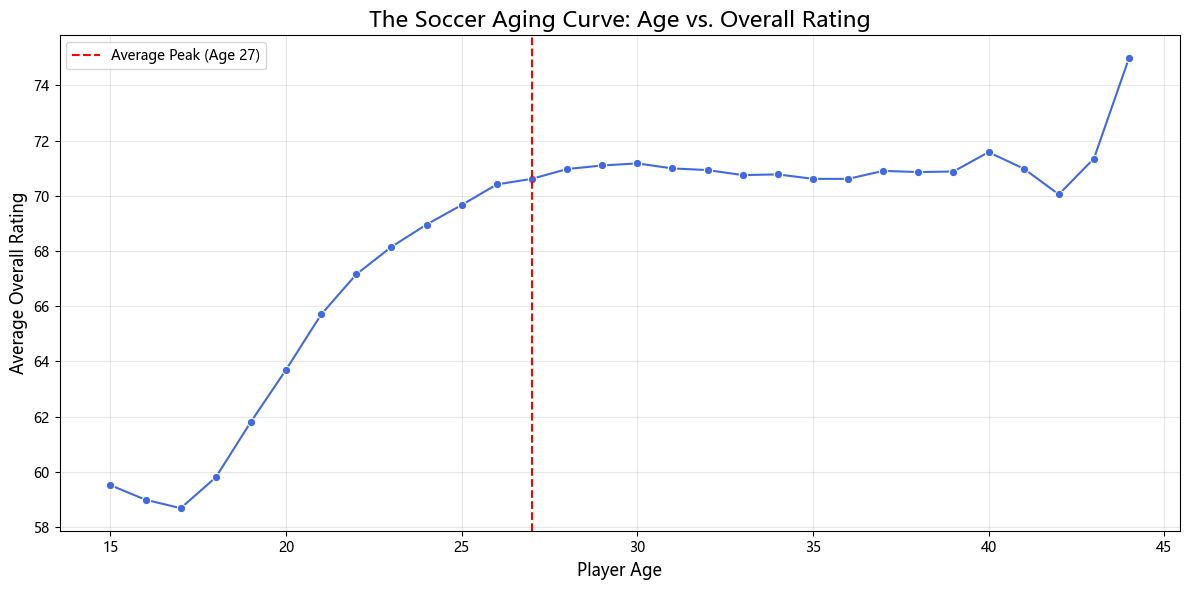

c:\Users\sherr\Desktop\campus\143\proj\143_football_match_analysis\visualization\visualization.py:705: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plt.suptitle(


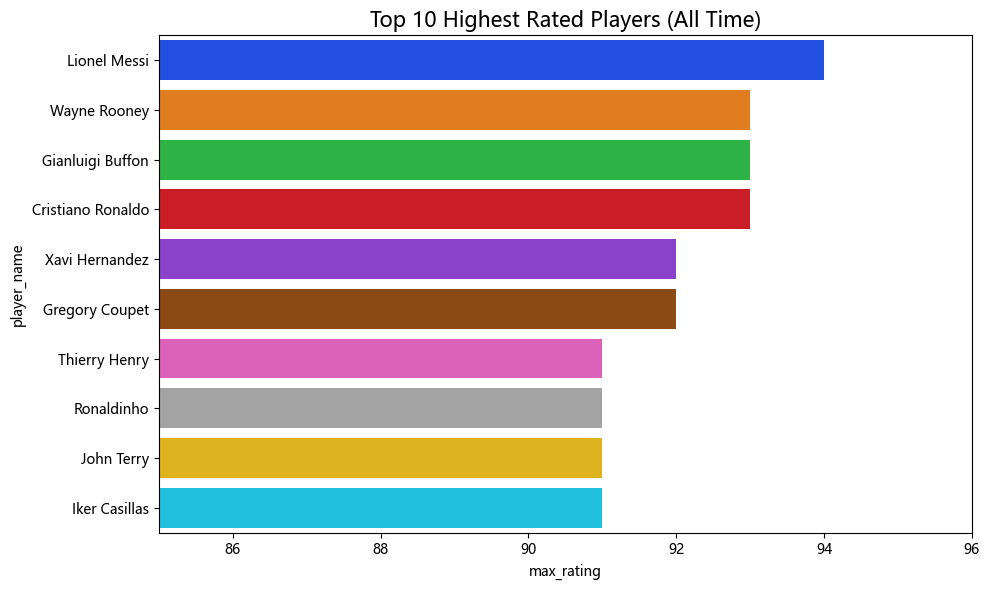

c:\Users\sherr\Desktop\campus\143\proj\143_football_match_analysis\visualization\visualization.py:731: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  )


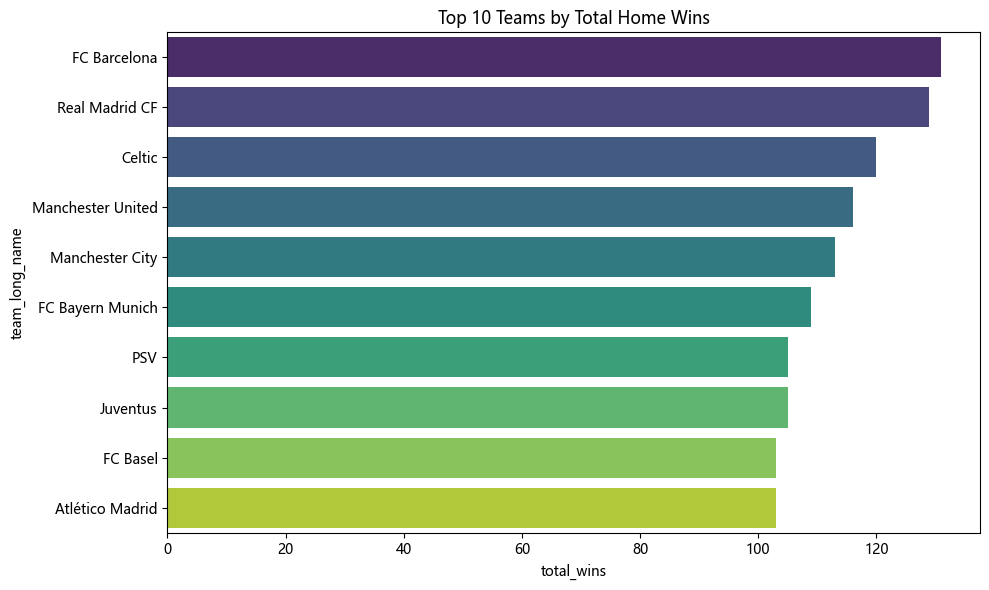

In [29]:
# Player & team analysis
from visualization.visualization import (
    load_aging_curve_df,
    plot_aging_curve,
    load_top_players,
    plot_top_rated_players,
    load_top_teams_home_wins,
    plot_top_teams_by_home_wins,
)

if DB_PATH.exists():
    df_age = load_aging_curve_df(DB_PATH)
    plot_aging_curve(df_age)
    top_players = load_top_players(DB_PATH)
    plot_top_rated_players(top_players)
    top_teams = load_top_teams_home_wins(DB_PATH)
    plot_top_teams_by_home_wins(top_teams)


## 5. Run Full Workflow

### 4.5 Non-Linear Visualization

From ECE143_Non-Linear_Visualization: aggression (fouls, cards) vs outcome, SVD dimensionality reduction, top-5-league correlation heatmaps, t-SNE vs Kernel PCA comparison.

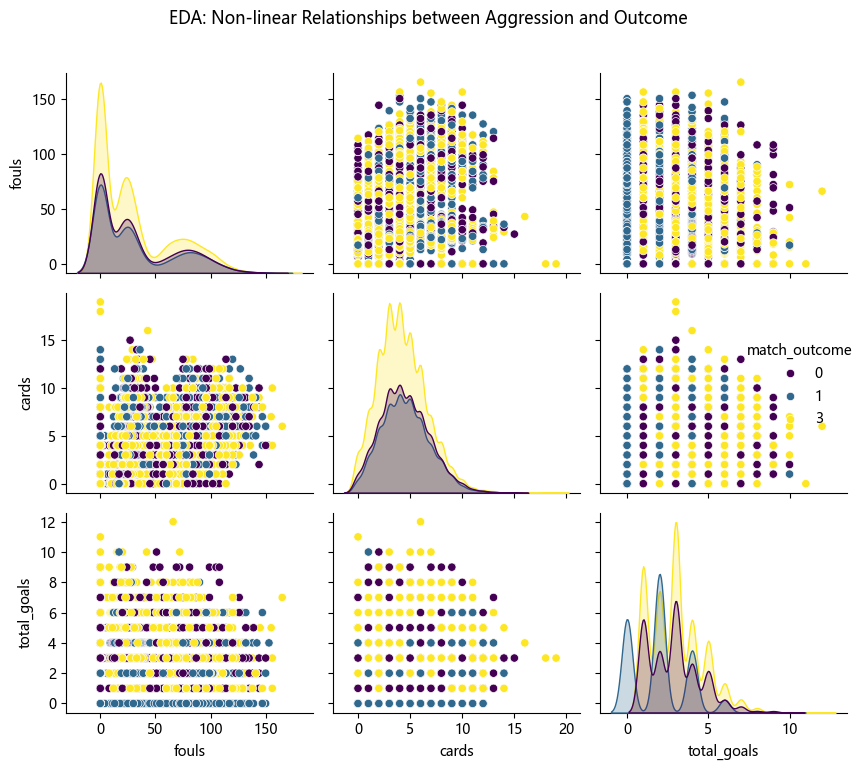

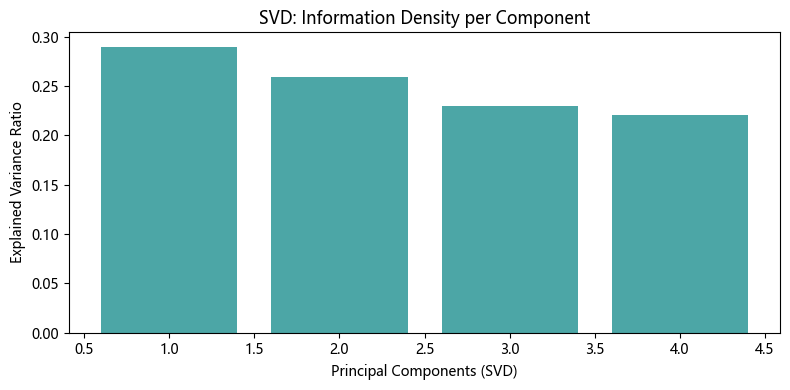

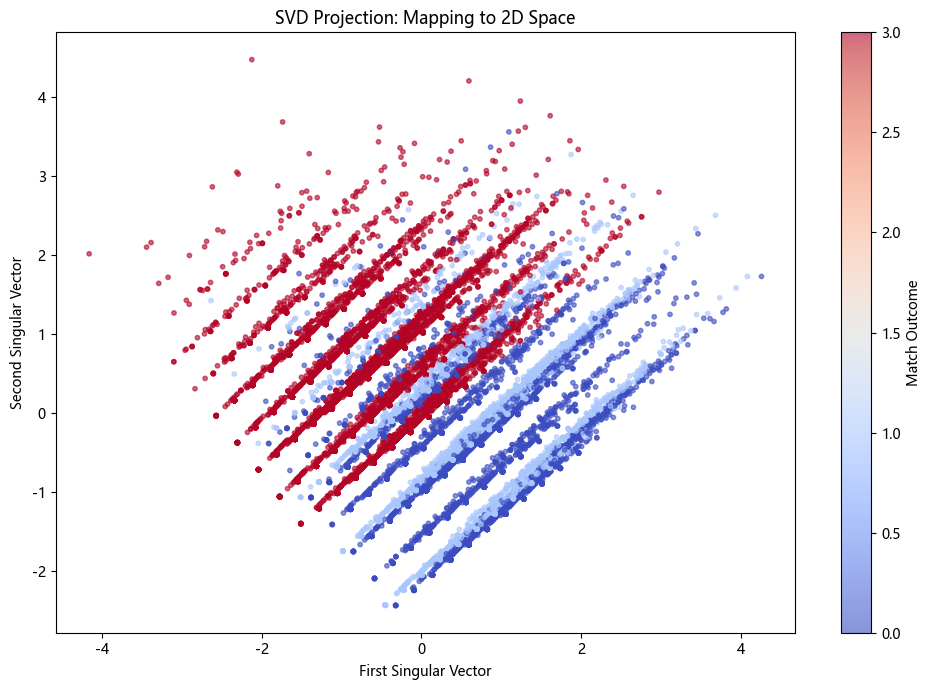

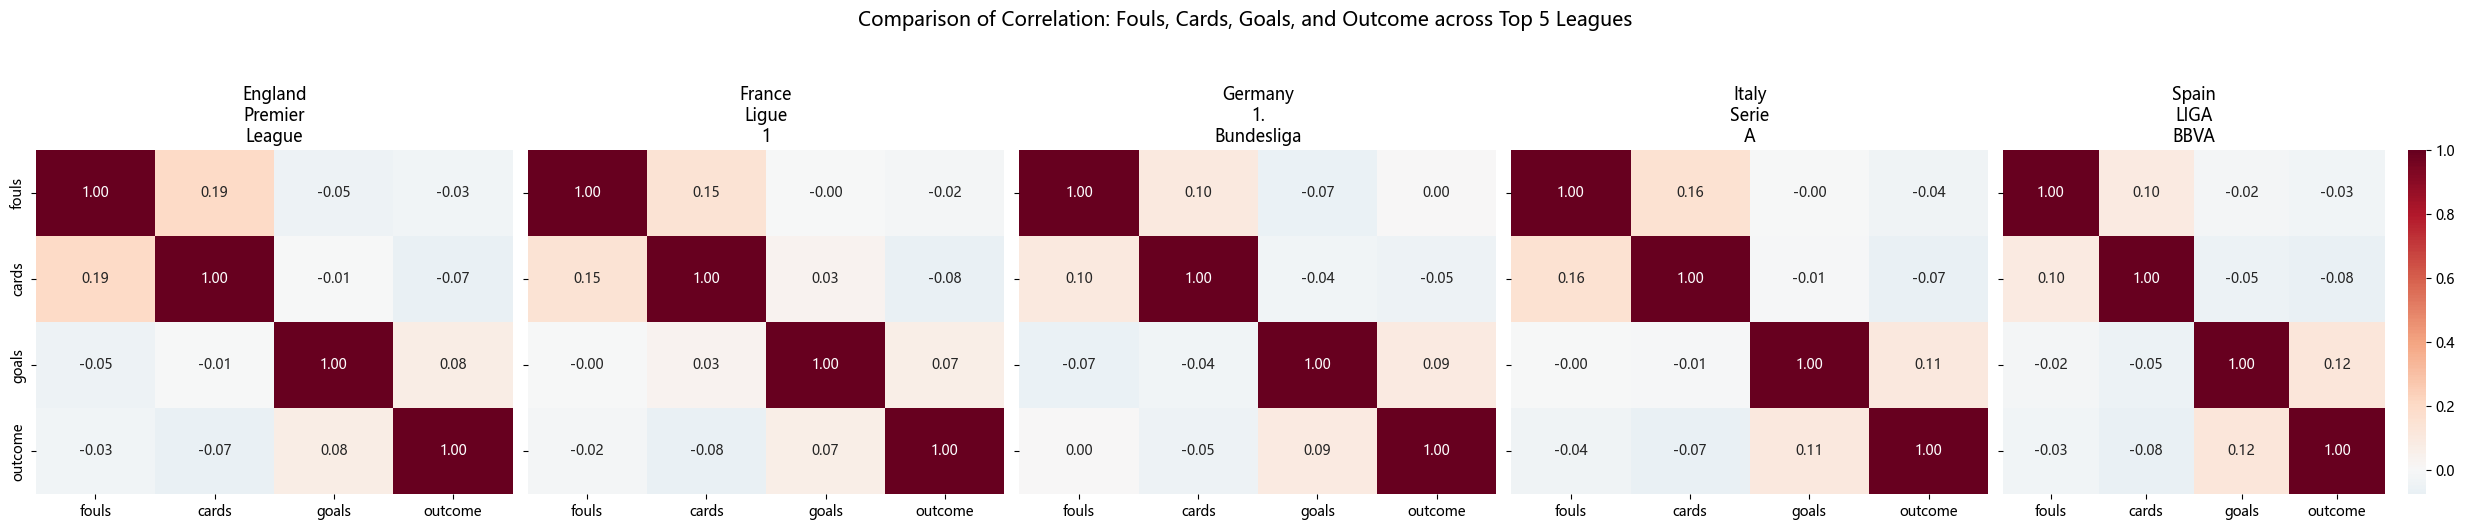

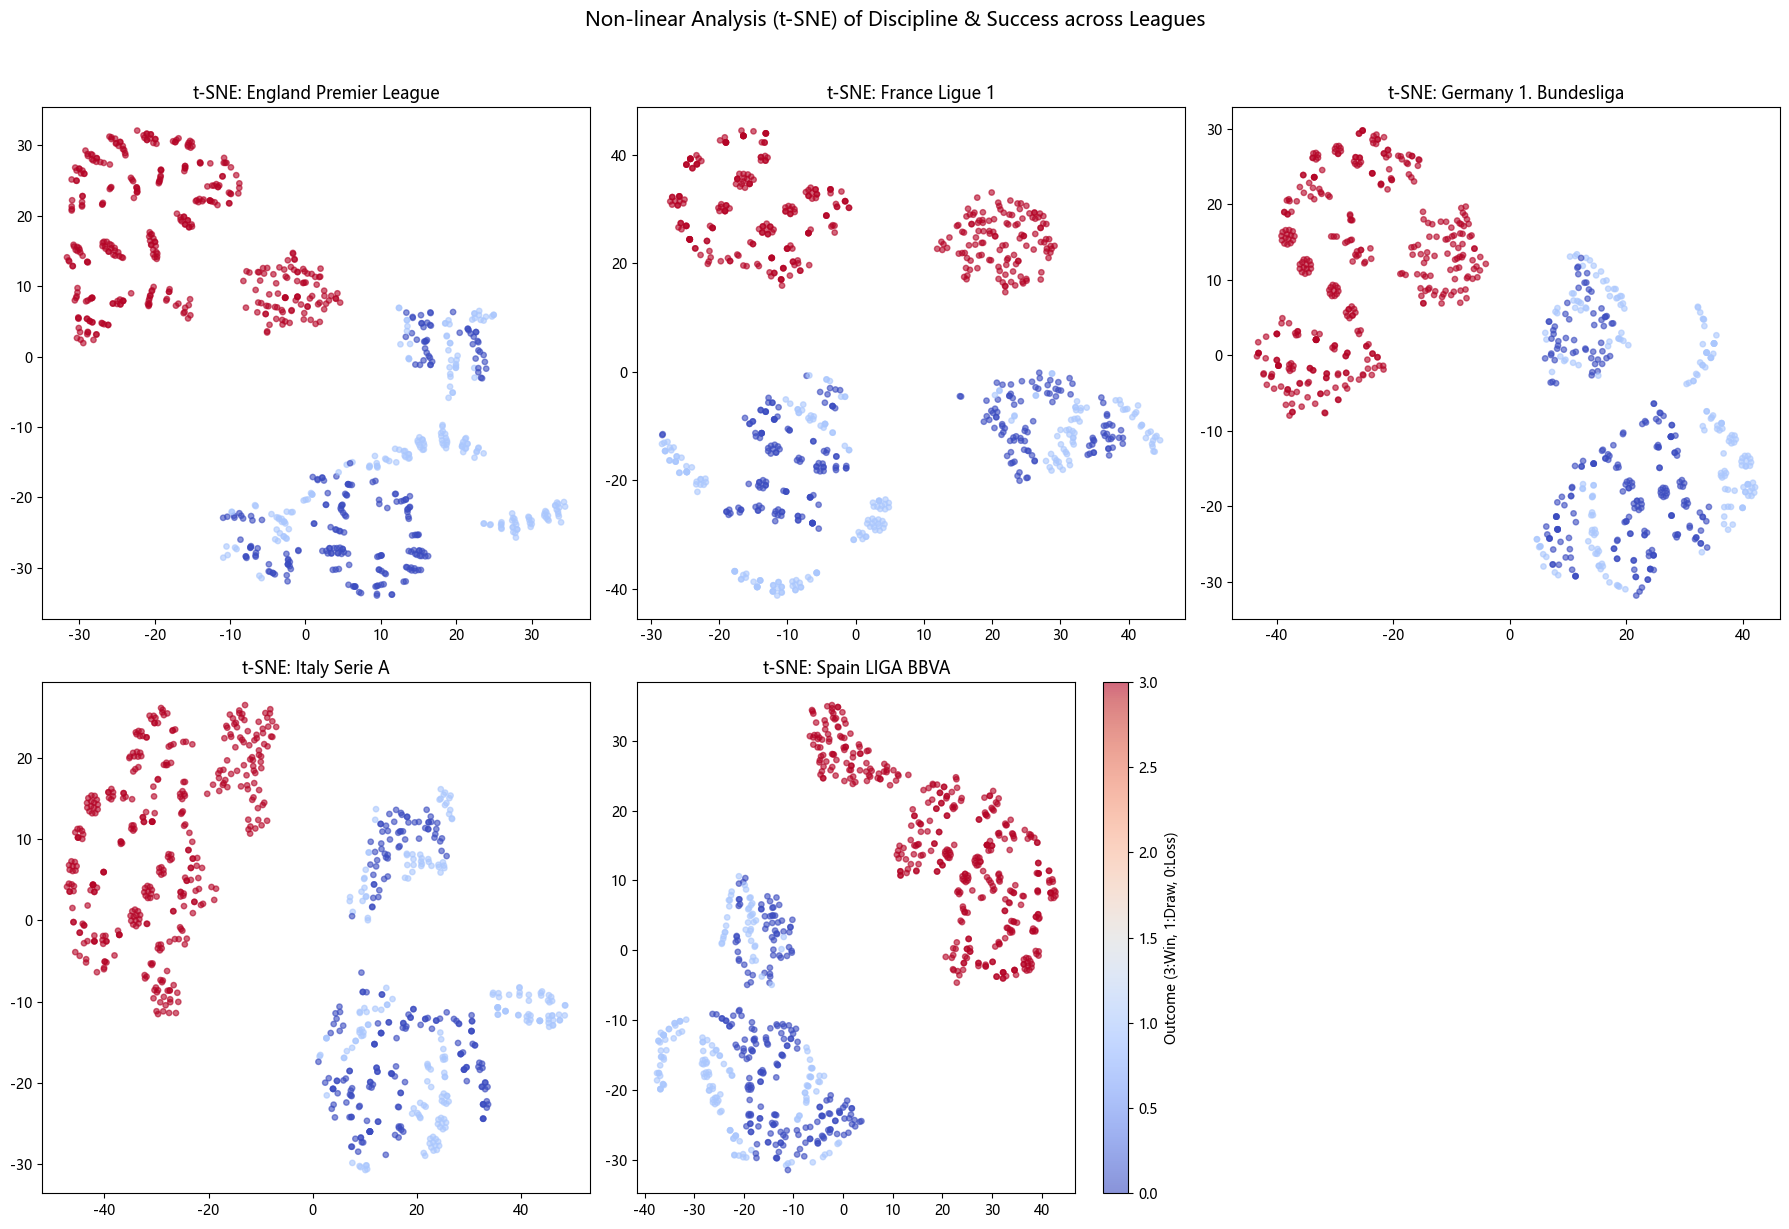

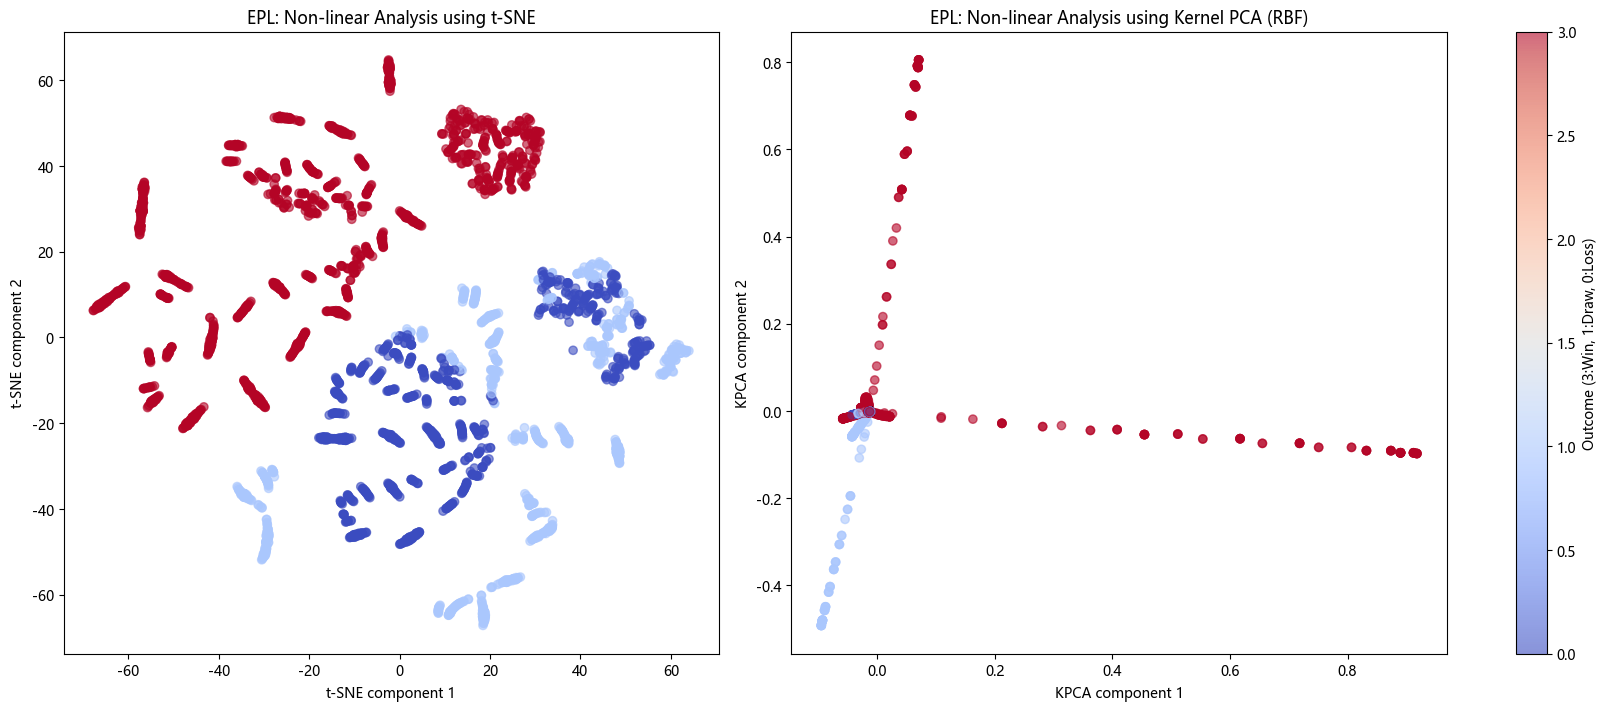

In [30]:
# Non-linear: SVD, t-SNE, Kernel PCA
import importlib
import visualization.visualization
importlib.reload(visualization.visualization)
from visualization.visualization import (
    load_aggression_eda_df,
    plot_aggression_outcome_pairplot,
    plot_svd_explained_variance_df,
    plot_svd_2d_projection_df,
    load_league_aggression_df,
    plot_league_correlation_comparison,
    plot_tsne_by_league,
    load_epl_aggression_df,
    plot_tsne_vs_kpca_epl,
)

if DB_PATH.exists():
    df_eda = load_aggression_eda_df(DB_PATH)
    if len(df_eda) > 0:
        plot_aggression_outcome_pairplot(df_eda)
        plot_svd_explained_variance_df(df_eda)
        plot_svd_2d_projection_df(df_eda)
    df_leagues = load_league_aggression_df(DB_PATH)
    if len(df_leagues) > 0:
        plot_league_correlation_comparison(df_leagues)
        plot_tsne_by_league(df_leagues)
    df_epl = load_epl_aggression_df(DB_PATH)
    if len(df_epl) > 0:
        plot_tsne_vs_kpca_epl(df_epl)
